#Error Dataset Creation


In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("/content/calisphere_simulation_data.csv")

# Create shifted columns (next timestep)
df["x_next"] = df["x"].shift(-1)
df["y_next"] = df["y"].shift(-1)
df["z_next"] = df["z"].shift(-1)

# Compute error (delta)
df["dx"] = df["x_next"] - df["x"]
df["dy"] = df["y_next"] - df["y"]
df["dz"] = df["z_next"] - df["z"]

# Drop last row (no next value)
df = df.dropna()

# Select final dataset
final_df = df[[
    "time_min",
    "x", "y", "z",
    "vx", "vy", "vz",
    "altitude",
    "bstar",
    "dx", "dy", "dz"
]]

# Save it
final_df.to_csv("/content/error_dataset.csv", index=False)

final_df.head()

,time_min,x,y,z,vx,vy,vz,altitude,bstar,dx,dy,dz
0,0,1218.069803,3377.219725,6390.148996,-2.131434,-6.081492,3.602797,958.618770,0.000692,-1417.427294,-4026.955085,904.447291
1,10,-199.357491,-649.735360,7294.596287,-2.449447,-6.932936,-0.679969,955.188261,0.000692,-1347.235556,-3798.172925,-1671.439587
2,20,-1546.593047,-4447.908285,5623.156700,-1.904732,-5.342526,-4.720898,963.557208,0.000692,-803.100421,-2233.263614,-3655.329482
3,30,-2349.693467,-6681.171899,1967.827218,-0.691633,-1.877505,-7.091203,979.609586,0.000692,20.853344,109.601262,-4348.408093
4,40,-2328.840124,-6571.570637,-2380.580875,0.757356,2.227021,-6.964614,996.238442,0.000692,832.484665,2399.904214,-3518.902445


#Training

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers

# Load dataset
df = pd.read_csv("error_dataset.csv")

# Features and target
X = df[["x","y","z","vx","vy","vz","altitude","bstar"]]
y = df[["dx","dy","dz"]]

# Normalize (VERY IMPORTANT)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Build model
model = tf.keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(3)  # dx, dy, dz
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

# Evaluate
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.9201 - mae: 0.8555 - val_loss: 0.7766 - val_mae: 0.7501
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.6268 - mae: 0.6997 - val_loss: 0.5394 - val_mae: 0.6175
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.4148 - mae: 0.5534 - val_loss: 0.3540 - val_mae: 0.4937
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2592 - mae: 0.4173 - val_loss: 0.2148 - val_mae: 0.3667
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1471 - mae: 0.2909 - val_loss: 0.1252 - val_mae: 0.2387
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0854 - mae: 0.2030 - val_loss: 0.0823 - val_mae: 0.1922
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0572 - mae: 0.1740 - val_loss: 0.0564 - val_mae: 0.1763
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0349 - mae: 0.1447 - val_loss: 0.0336 - val_mae: 0.1367
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0193 - mae: 0.1041 -

#Prediction

In [ ]:
y_pred = model.predict(X_test_reshaped)

# Convert back
y_pred_actual = scaler_y.inverse_transform(y_pred)
y_test_actual = scaler_y.inverse_transform(y_test)

# Compare
for i in range(5):
    print("Pred:", y_pred_actual[i], "Actual:", y_test_actual[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Pred: [   2.7235448   10.418632  -103.172264 ] Actual: [ -900.77269778 -2515.10541159 -3443.95688725]
Pred: [ -4.3493466  -5.758861  -22.464092 ] Actual: [-269.23092355 -812.63209494 4269.85257229]
Pred: [ -5.232589   -1.7461938 -21.959621 ] Actual: [ -435.31020307 -1282.5459786   4140.83166016]
Pred: [  5.6375847  18.160173  -98.031075 ] Actual: [ -157.16341986  -395.39204808 -4330.53085431]
Pred: [  6.9044633  21.455471  -95.73848  ] Actual: [  579.56581746  1689.10373654 -3958.87900159]


#LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

# Clear any previous TensorFlow graph and Keras state
tf.keras.backend.clear_session()

# Define SEQ_LEN and reshape data for LSTM input
SEQ_LEN = 1  # Assuming each sample is a single timestep
num_features = X_train.shape[1]

X_train_reshaped = X_train.reshape(X_train.shape[0], SEQ_LEN, num_features)
X_test_reshaped = X_test.reshape(X_test.shape[0], SEQ_LEN, num_features)

model = Sequential([
    Input(shape=(SEQ_LEN, num_features)), # Using Input layer as suggested by Keras
    LSTM(64, return_sequences=True),
    Dropout(0.1),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(3)  # dx, dy, dz
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mse']
)

# Define ModelCheckpoint callback to save the best model based on validation MAE
checkpoint_callback = ModelCheckpoint(
    filepath='best_lstm_model.keras',
    monitor='val_mse', # Monitor validation Mean Absolute Error
    save_best_only=True, # Save only the best model
    mode='min', # 'min' because we want to minimize MAE
    verbose=1 # Log when a better model is saved
)

In [ ]:
history = model.fit(
    X_train_reshaped, y_train,
    epochs=40,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.9909 - mse: 0.9909 - val_loss: 0.9746 - val_mse: 0.9746
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9555 - mse: 0.9555 - val_loss: 0.9400 - val_mse: 0.9400
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9190 - mse: 0.9190 - val_loss: 0.8977 - val_mse: 0.8977
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8690 - mse: 0.8690 - val_loss: 0.8410 - val_mse: 0.8410
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8157 - mse: 0.8157 - val_loss: 0.7693 - val_mse: 0.7693
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7394 - mse: 0.7394 - val_loss: 0.6792 - val_mse: 0.6792
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6421 - mse: 0.6421 - val_loss: 0.5689 - val_mse: 0.5689
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5281 - mse: 0.5281 - val_loss: 0.4438 - val_mse: 0.4438
Epoch 9/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4000 - mse: 0.4000 - 

In [ ]:
model.save('lstm_debris_error_prediction_model.keras')

#Test

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,779 (378.05 KB)

 Trainable params: 32,259 (126.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,520 (252.04 KB)

In [ ]:
model.evaluate(X_test_reshaped, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0014 - mse: 0.0014


[0.0013874523574486375, 0.0013874523574486375]

In [ ]:
loss, mse = model.evaluate(X_test_reshaped, y_test)
print("Test MAE:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0014 - mse: 0.0014
Test MAE: 0.0013874523574486375


In [ ]:
y_pred = model.predict(X_test_reshaped)

# Convert back
y_pred_actual = scaler_y.inverse_transform(y_pred)
y_test_actual = scaler_y.inverse_transform(y_test)

# Compare
for i in range(5):
    print("Pred:", y_pred_actual[i], "Actual:", y_test_actual[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Pred: [ -892.4927 -2601.1653 -3427.27  ] Actual: [ -900.77269778 -2515.10541159 -3443.95688725]
Pred: [-243.35535 -867.4107  4020.5886 ] Actual: [-269.23092355 -812.63209494 4269.85257229]
Pred: [ -406.78784 -1307.2338   3910.7617 ] Actual: [ -435.31020307 -1282.5459786   4140.83166016]
Pred: [ -147.59961  -275.60422 -4336.0938 ] Actual: [ -157.16341986  -395.39204808 -4330.53085431]
Pred: [  537.8286  1557.3551 -3914.0466] Actual: [  579.56581746  1689.10373654 -3958.87900159]


In [ ]:
# Take last sequence
current_seq = X_test_reshaped[-1].reshape(1, SEQ_LEN, X_test_reshaped.shape[2])

predicted_delta = model.predict(current_seq)
predicted_delta = scaler_y.inverse_transform(predicted_delta)

print("Predicted Δ:", predicted_delta)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
Predicted Δ: [[ 1377.3242  3849.7659 -1130.777 ]]


In [ ]:
#Predict

In [ ]:
# Predict using correct input
y_pred = model.predict(X_test_reshaped)

# Convert back to original scale
y_pred_actual = scaler_y.inverse_transform(y_pred)
y_test_actual = scaler_y.inverse_transform(y_test)

# Get corresponding current states (last timestep of each sequence)
X_test_actual = scaler_X.inverse_transform(
    X_test_reshaped[:, -1, :]   # correct for sequence data
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [ ]:
# Extract current position
x_curr = X_test_actual[:, 0]
y_curr = X_test_actual[:, 1]
z_curr = X_test_actual[:, 2]

# LSTM predicted next position
x_pred = x_curr + y_pred_actual[:, 0]
y_pred_pos = y_curr + y_pred_actual[:, 1]
z_pred = z_curr + y_pred_actual[:, 2]

# Actual next position (ground truth)
x_true = x_curr + y_test_actual[:, 0]
y_true = y_curr + y_test_actual[:, 1]
z_true = z_curr + y_test_actual[:, 2]

In [ ]:
import numpy as np

rmse = np.sqrt(np.mean(
    (x_pred - x_true)**2 +
    (y_pred_pos - y_true)**2 +
    (z_pred - z_true)**2
))

print("LSTM RMSE:", rmse)

LSTM RMSE: 179.36078072699902


In [ ]:
# naive baseline: assume no change
x_base = x_curr
y_base = y_curr
z_base = z_curr

rmse_base = np.sqrt(np.mean(
    (x_base - x_true)**2 +
    (y_base - y_true)**2 +
    (z_base - z_true)**2
))

print("Baseline RMSE:", rmse_base)

Baseline RMSE: 4348.607745254266


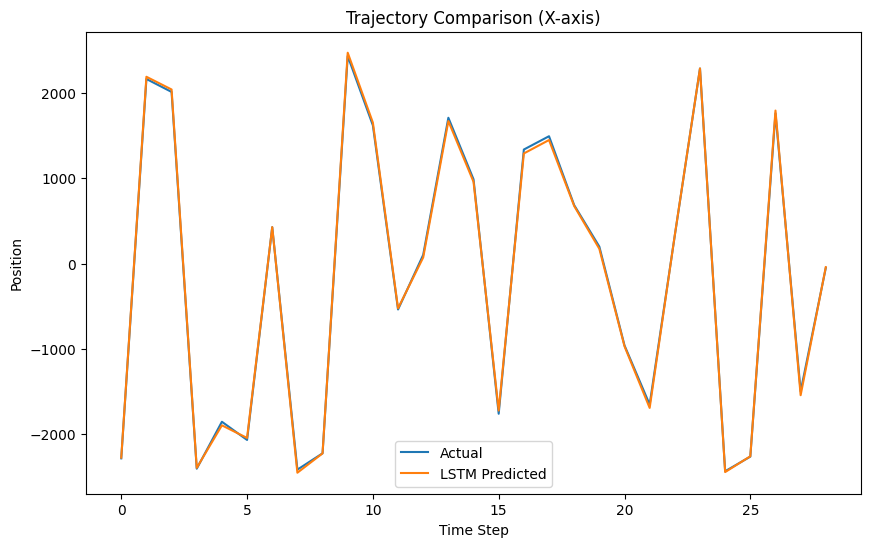

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Plot only few points
plt.plot(x_true[:50], label="Actual")
plt.plot(x_pred[:50], label="LSTM Predicted")

plt.legend()
plt.title("Trajectory Comparison (X-axis)")
plt.xlabel("Time Step")
plt.ylabel("Position")
plt.show()

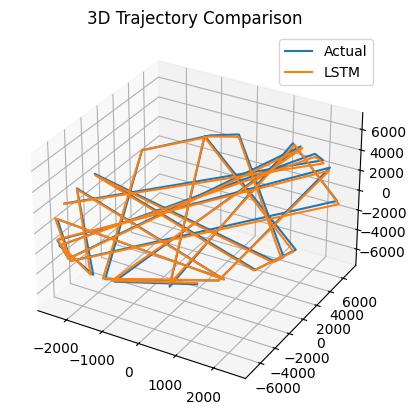

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_true[:100], y_true[:100], z_true[:100], label="Actual")
ax.plot(x_pred[:100], y_pred_pos[:100], z_pred[:100], label="LSTM")

ax.legend()
plt.title("3D Trajectory Comparison")
plt.show()